In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from transformer_lens import HookedTransformer

In [2]:
MODEL: HookedTransformer = HookedTransformer.from_pretrained("gpt2-small")

Loaded pretrained model gpt2-small into HookedTransformer


In [ ]:
# print(condense_tensor_dict(cache, fmt="yaml"))

blocks:
  '[0-11]':
    ln1:
      hook_scale: (1, 56, 1)
      hook_normalized: (1, 56, 768)
    attn:
      '[hook_q, hook_k, hook_v, hook_z]': (1, 56, 12, 64)
      '[hook_attn_scores, hook_pattern]': (1, 12, 56, 56)
    ln2:
      hook_scale: (1, 56, 1)
      hook_normalized: (1, 56, 768)
    mlp:
      '[hook_pre, hook_post]': (1, 56, 3072)
    '[hook_resid_pre, hook_attn_out, hook_resid_mid, hook_mlp_out, hook_resid_post]': (1,
      56, 768)
ln_final:
  hook_scale: (1, 56, 1)
  hook_normalized: (1, 56, 768)
'[hook_embed, hook_pos_embed]': (1, 56, 768)



In [37]:
def plot_attn_tok_axes(
	prompt: str,
	idx: tuple[int, int] | str,
	model: HookedTransformer = MODEL,
) -> None:
	layer_idx: int
	head_idx: int
	if isinstance(idx, tuple):
		layer_idx, head_idx = idx
	elif isinstance(idx, str):
		# assume it is of format "L1H2" or such
		raise NotImplementedError("not done yet")

	logits, cache = MODEL.run_with_cache([prompt])
	tokens: list[str] = [x.replace("Ġ", " ") for x in MODEL.tokenizer.tokenize(prompt)]
	n_tokens: int = len(tokens)
	figsize: float = n_tokens / 5
	fig, ax = plt.subplots(figsize=(figsize, figsize))
	ax.imshow(cache[f"blocks.{layer_idx}.attn.hook_pattern"][0, head_idx].cpu().numpy())
	ax.set_xticks(np.arange(len(tokens)), tokens, rotation=90)
	ax.set_yticks(np.arange(len(tokens)), tokens)

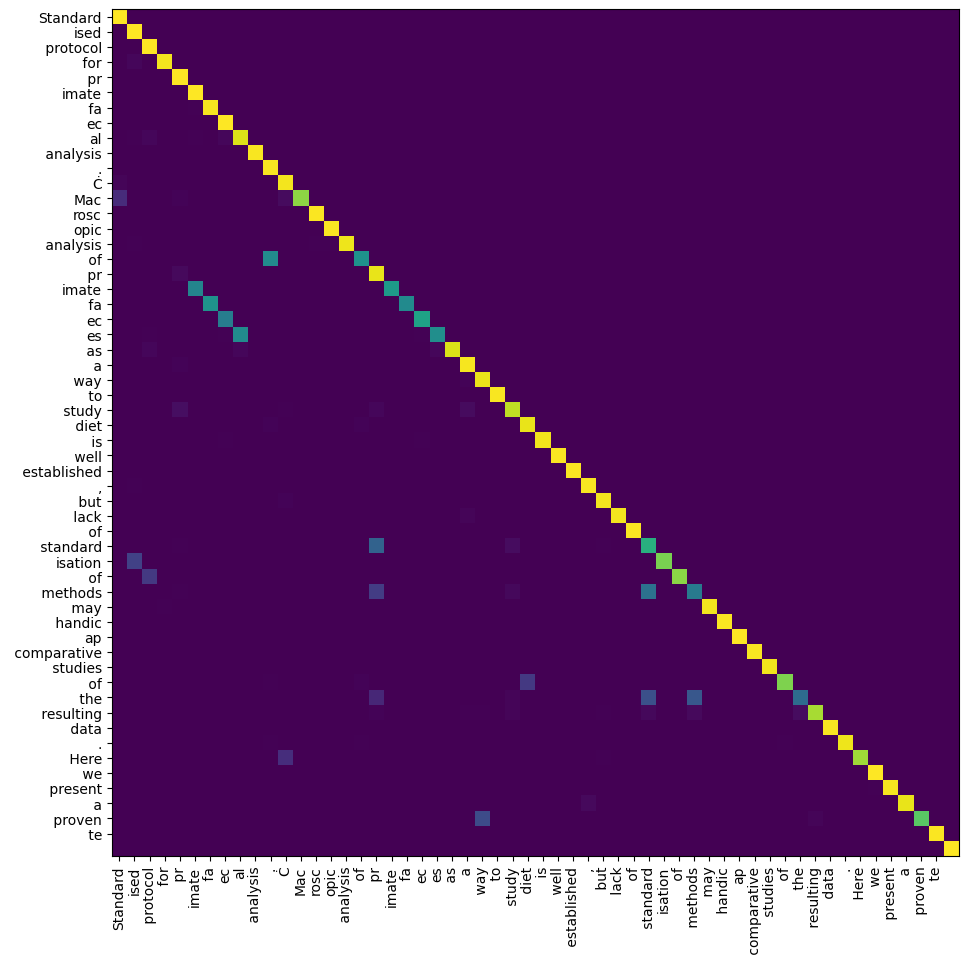

In [38]:
plot_attn_tok_axes(
	idx=(0, 1),
	prompt="""Standardised protocol for primate faecal analysis.
Macroscopic analysis of primate faeces as a way to study diet is well established, but lack of standardisation of methods may handicap comparative studies of the resulting data. Here we present a proven te""",
)

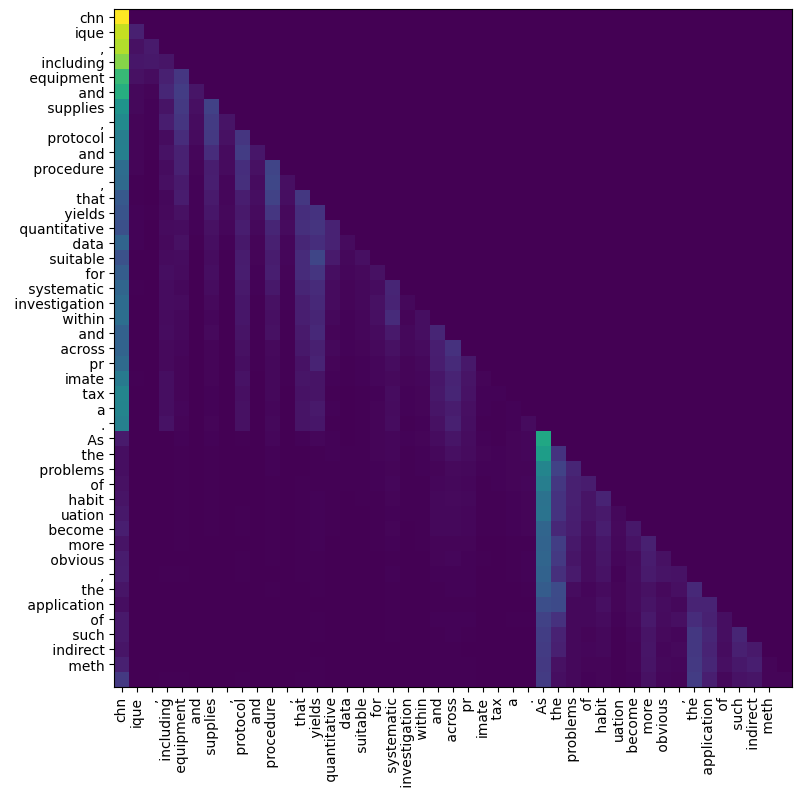

In [39]:
plot_attn_tok_axes(
	idx=(2, 6),
	prompt="""chnique, including equipment and supplies, protocol and procedure, that yields quantitative data suitable for systematic investigation within and across primate taxa. As the problems of habituation become more obvious, the application of such indirect meth""",
)